In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import dill
import jax
import jax.numpy as jnp
import json
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import scipy
import torch

from flax import nnx
from torch.utils.data import DataLoader
from typing import Any, NamedTuple
from typing_extensions import Protocol, runtime_checkable

from src.constants import *
from src.dataset import get_iter
from src.datasets.sum import Addition
from src.decoding import make_autoregressive
from src.rollout import rollout
from src.utils import parse_dict
from src.verifier import make_compute_returns

In [3]:
base_path = "/home/bryanpu1/projects/parallel_vs_serial/scaling_jax/results"
algo_name = "addition-max_int_64-no_eos-reset_immediately"
run_name = "ppo-scratch_1M-traj_improvement-discounting-0_cot_tokens-8x8-01-23-26_12_09_26-f286ef45-3656-4c3c-9de7-8c8fdae668ed"
# run_name = "ppo_kl-scratch_1M-0_cot_tokens-8x8-01-23-26_11_05_40-93cc131e-8f27-4175-88b1-51de541e4d0b"

learner_path = os.path.join(base_path, algo_name, run_name)

eval_seed = 42
num_evals = 1
max_decode_len = 1000
batch_size = 32
max_bits = 10

config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))
half_precision = config_dict["half_precision"]
dtype = jnp.bfloat16 if half_precision else jnp.float32

# Get dataset
max_int = int(2 ** max_bits)
config = parse_dict(config_dict)
dataset_kwargs = config.dataset_kwargs

## Rollout

In [4]:
if config.dataset_name == "curriculum":
    max_num_bits = int(np.ceil(np.log2(dataset_kwargs.datasets[-1]["dataset_kwargs"]["max_int"])))
    train_val_ratio = dataset_kwargs.datasets[-1]["dataset_kwargs"]["train_val_ratio"]
    predict_eos = dataset_kwargs.datasets[-1]["dataset_kwargs"]["predict_eos"]
    num_cot_tokens = dataset_kwargs.datasets[-1]["dataset_kwargs"]["num_cot_tokens"]
    right_to_left = dataset_kwargs.datasets[-1]["dataset_kwargs"]["right_to_left"]
    correctness_aware = dataset_kwargs.datasets[-1]["dataset_kwargs"]["correctness_aware"]
    carry_registers = dataset_kwargs.datasets[-1]["dataset_kwargs"]["carry_registers"]
    train_max_decode_len = dataset_kwargs.datasets[-1]["dataset_kwargs"]["context_len"]
else:
    max_num_bits = int(np.ceil(np.log2(dataset_kwargs.max_int)))
    train_val_ratio = dataset_kwargs.train_val_ratio
    predict_eos = dataset_kwargs.predict_eos
    num_cot_tokens = dataset_kwargs.num_cot_tokens
    right_to_left = dataset_kwargs.right_to_left
    correctness_aware = dataset_kwargs.correctness_aware
    carry_registers = getattr(dataset_kwargs, "carry_registers", False)
    train_max_decode_len = dataset_kwargs.context_len

dataset = Addition(
    context_len=max_decode_len,
    max_int=max_int,
    train=False,
    seed=eval_seed,
    sequence_type="question_only",
    train_val_ratio=train_val_ratio,
    right_to_left=right_to_left,
    num_repeats=None,
    shuffle=False,
    exact=False,
    predict_eos=predict_eos,
    num_cot_tokens=num_cot_tokens,
    p_curriculum=0.0,
    p_inject_noop=0.0,
    max_noops=0,
    noop_as_pad=False,
    reverse_curriculum=False,
    correctness_aware=correctness_aware,
    carry_registers=carry_registers,
)

out_dim = int(dataset.output_space.n)
data_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    num_workers=0,
)
data_iter = get_iter(data_loader, None, dtype)
batch = next(data_iter)
batch = {
    k: np.repeat(v, num_evals, axis=0)
    for k, v in batch.items()
}

EOS TOKEN: 6
TOKEN MAP: {0: 0, 1: 1, 2: 2, 3: 3, 6: 6, 4: 4, 5: 5}


In [ ]:
config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

# Load model
last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[-1]
train_state = dill.load(
    open(os.path.join(learner_path, "models", last_step), "rb")
)

model = nnx.merge(
    train_state.graphdef,
    train_state.params,
    train_state.rest,
)

rng = jax.random.PRNGKey(eval_seed)
rng, rollout_rng = jax.random.split(rng)

# Sample next batch and evaluate
_, init_cache = make_autoregressive(
    model,
    max_decode_len=max_decode_len,
    batch_size=batch_size * num_evals,
    embed_dim=config_dict["model_config"]["model_kwargs"]["embed_dim"],
    dtype=dtype,
    eval_mode=True,
)
cache = init_cache()
graphdef, _, rest = nnx.split(model, nnx.Cache, ...)

In [ ]:
rollout_res = rollout(
    graphdef,
    cache,
    rest,
    rollout_rng,
    batch,
    eos_token=dataset.eos_token_id,
    deterministic=0,
    correct_aware_shift=dataset.correctness_aware_tokens_offset,
    max_token_id_to_shift=dataset.max_token_id_to_shift,
)

In [ ]:
reset_mask = (rollout_res.observations * rollout_res.pred_mask) == dataset.reset_token_id

In [ ]:
all_trials = []
for sample_i, (
    observations,
    pred_mask,
    response_length,
    question_len,
) in enumerate(zip(
    rollout_res.observations,
    rollout_res.pred_mask,
    rollout_res.response_length,
    batch["question_len"],
)):
    pred_traj = observations * pred_mask
    pred_traj = pred_traj.at[question_len + response_length].set(dataset.reset_token_id)
    reset_idxes = np.where(pred_traj == dataset.reset_token_id)[0]
    per_sample_trials = dict()
    first_ooc_trial = -1
    for trial_i, (start_idx, end_idx) in enumerate(zip(reset_idxes[:-1], reset_idxes[1:])):
        curr_trial = "".join(map(str, pred_traj[start_idx:end_idx]))
        per_sample_trials.setdefault(curr_trial, [])
        per_sample_trials[curr_trial].append(trial_i)
        if end_idx <= train_max_decode_len:
            first_ooc_trial = trial_i + 1

    all_trials.append((len(reset_idxes) - 1, first_ooc_trial, per_sample_trials))

In [ ]:
jnp.mean(rollout_res.success.reshape((batch_size, num_evals)), axis=-1)

Array([1., 0., 1., 1.], dtype=float32)

## TODO:
- Success rate at OOD context length (not the question length, but context usage)

Sample: 0, Success: True, Required attempts: 5


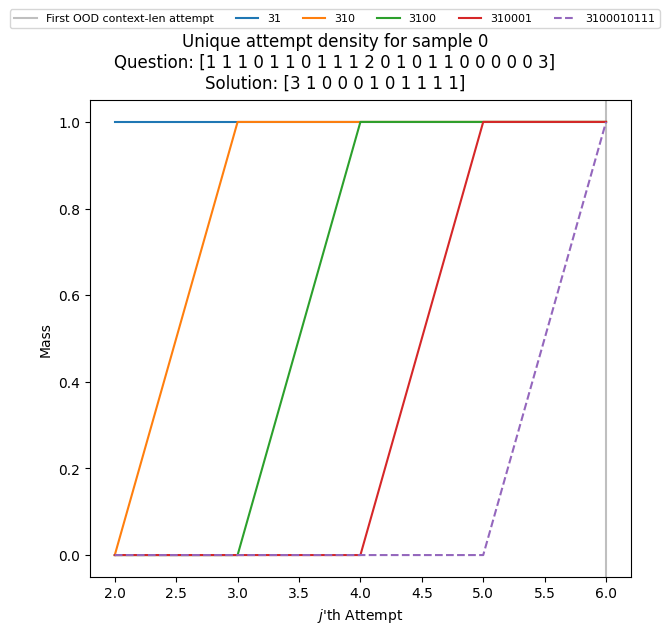

Sample: 1, Success: True, Required attempts: 5


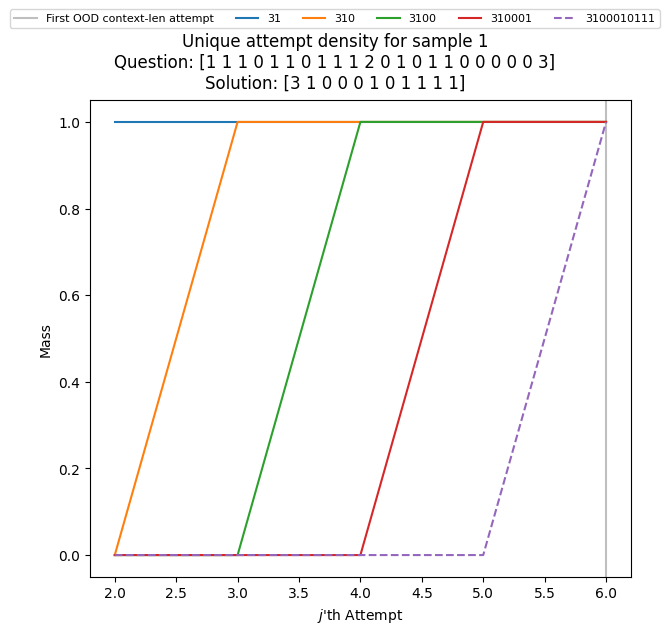

Sample: 2, Success: True, Required attempts: 5


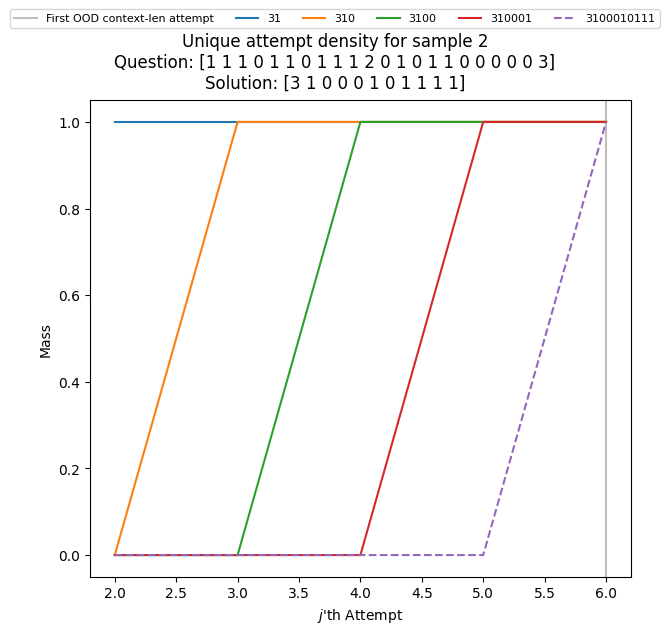

Sample: 3, Success: True, Required attempts: 5


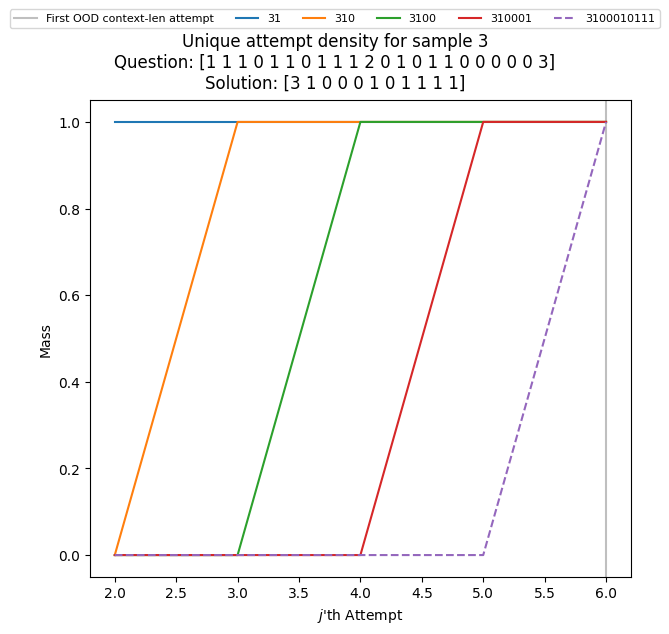

Sample: 4, Success: True, Required attempts: 5


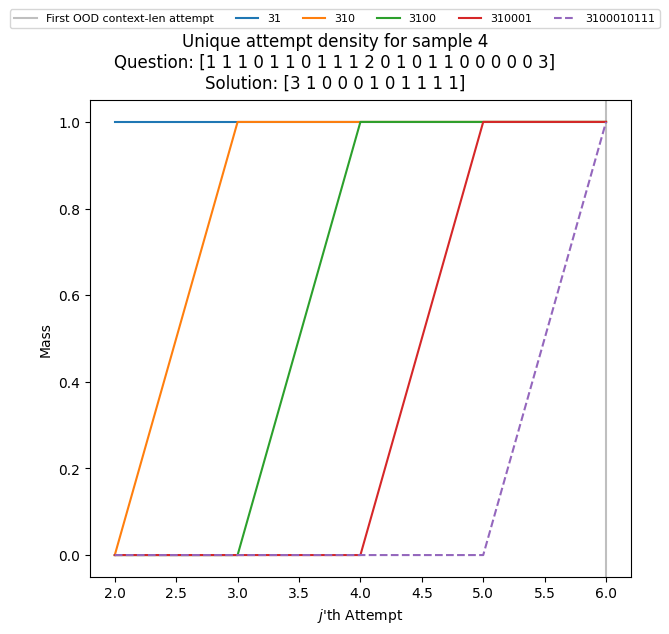

Sample: 5, Success: True, Required attempts: 5


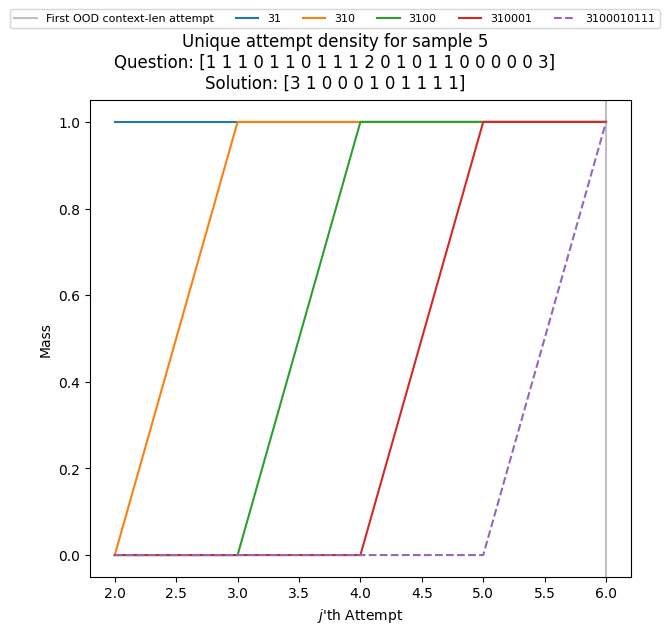

Sample: 6, Success: True, Required attempts: 5


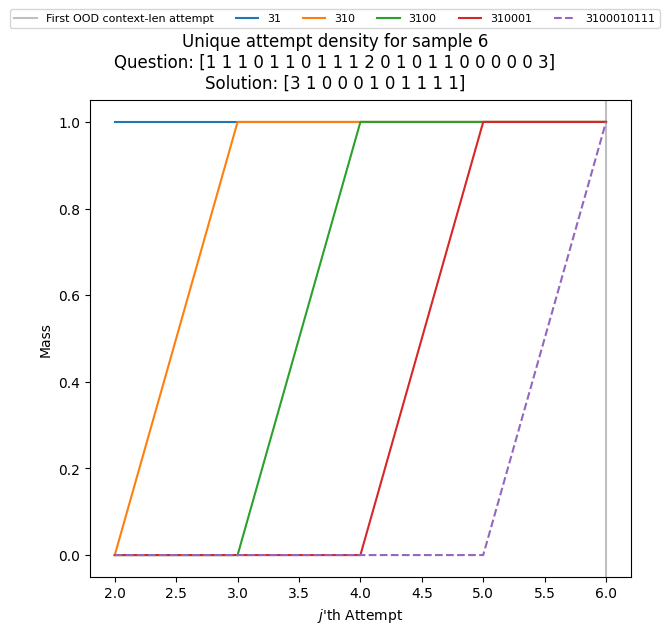

Sample: 7, Success: True, Required attempts: 5


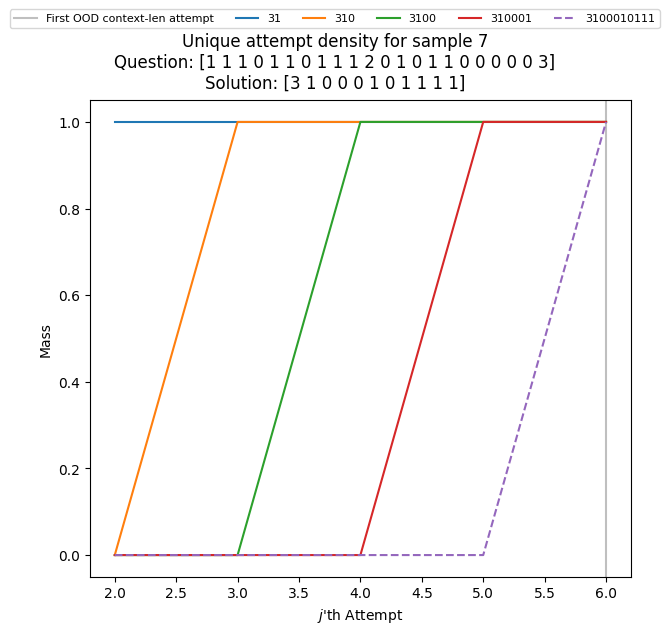

Sample: 8, Success: False, Required attempts: 385


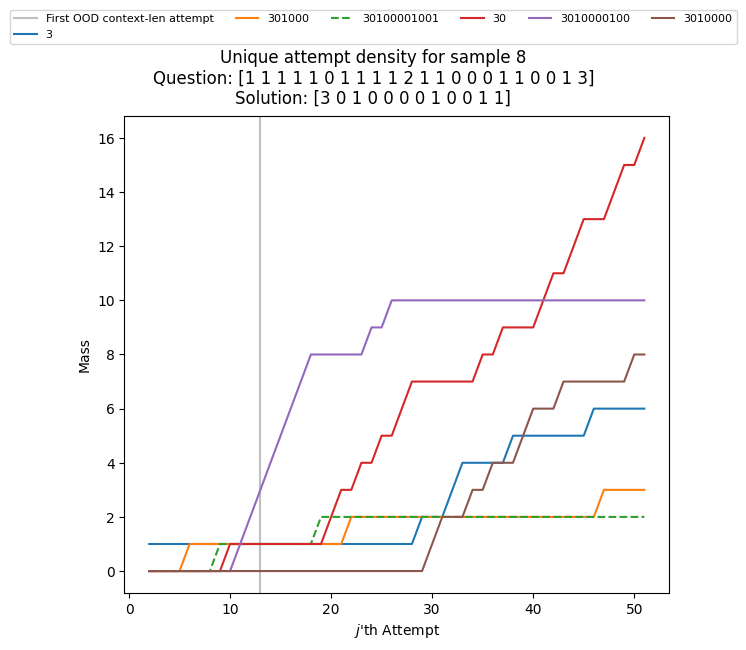

Sample: 9, Success: False, Required attempts: 367


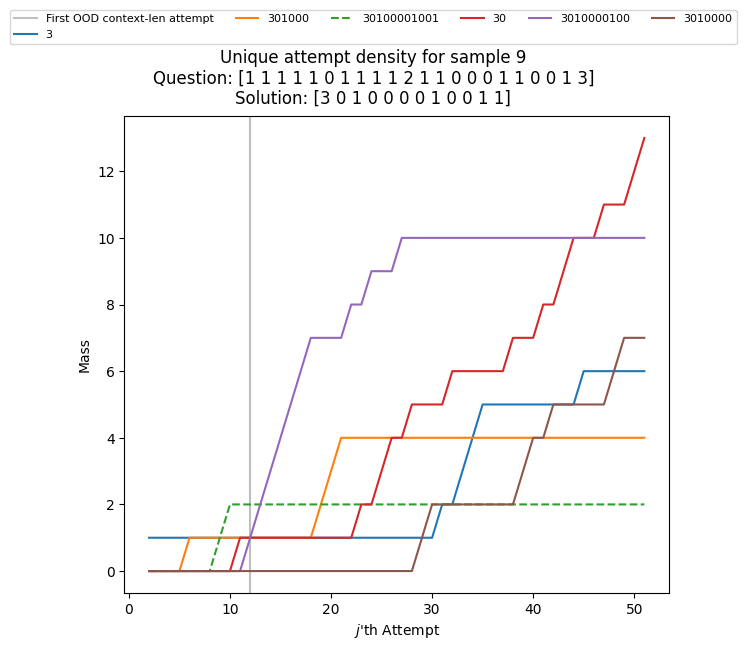

Sample: 10, Success: False, Required attempts: 374


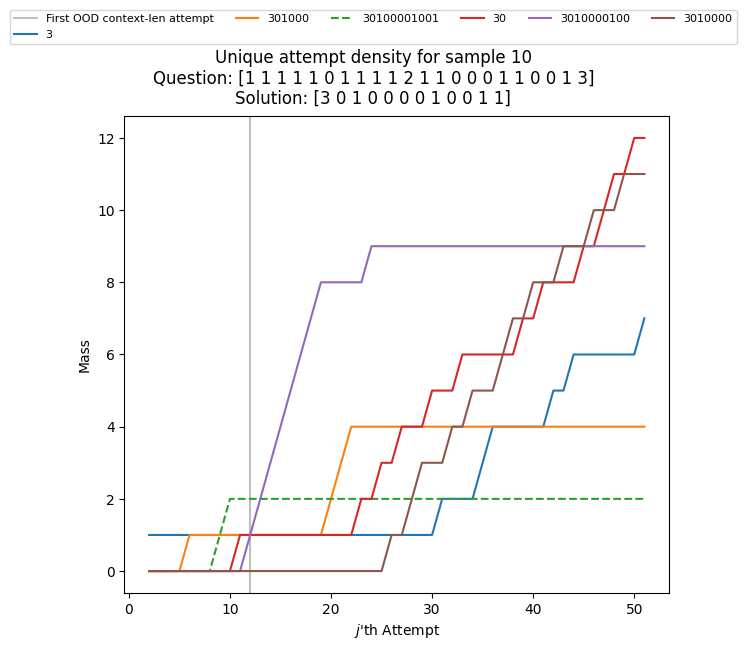

Sample: 11, Success: False, Required attempts: 376


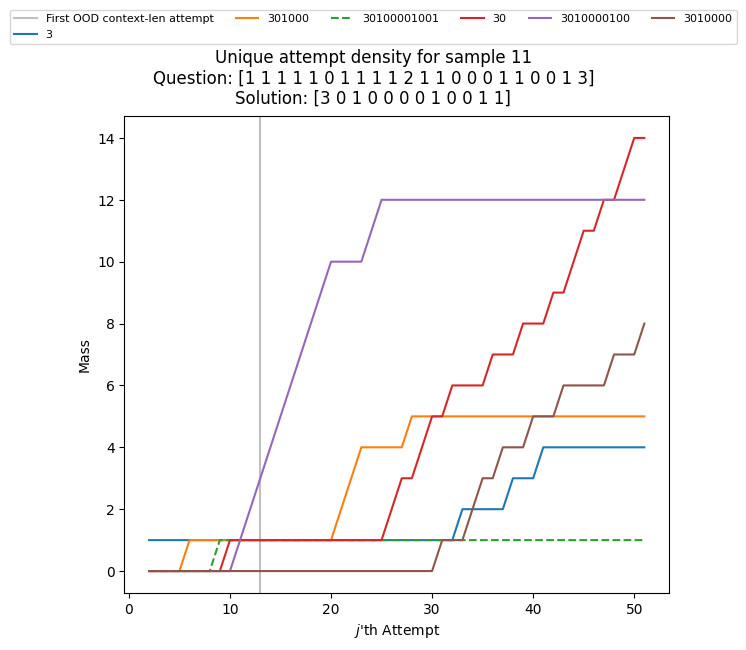

Sample: 12, Success: False, Required attempts: 356


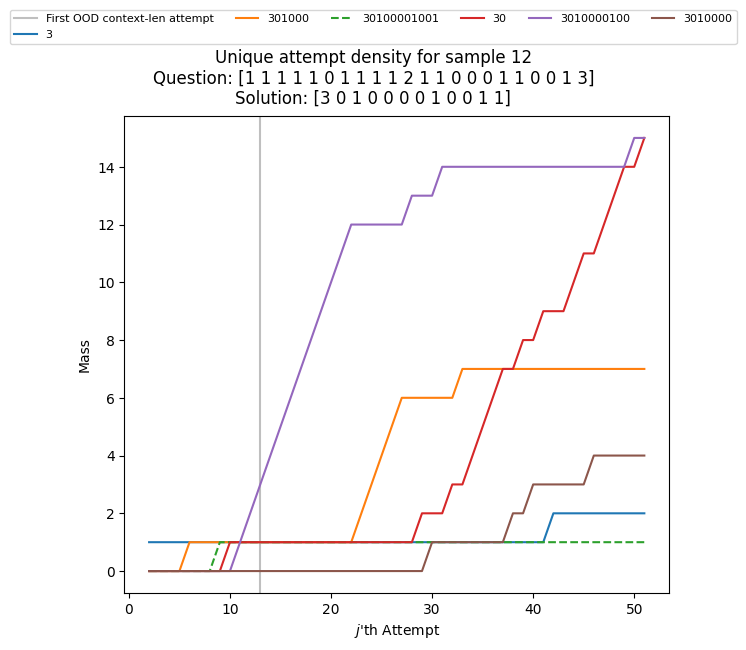

Sample: 13, Success: False, Required attempts: 372


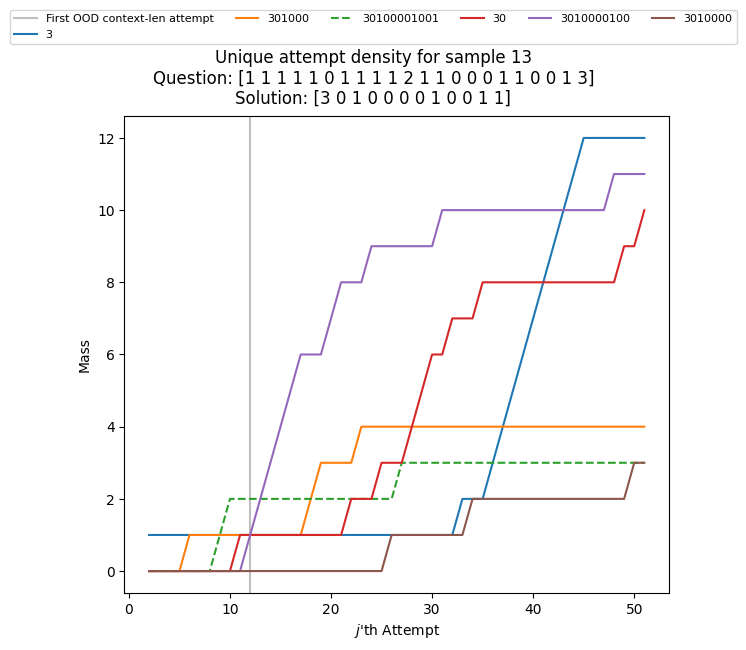

Sample: 14, Success: False, Required attempts: 368


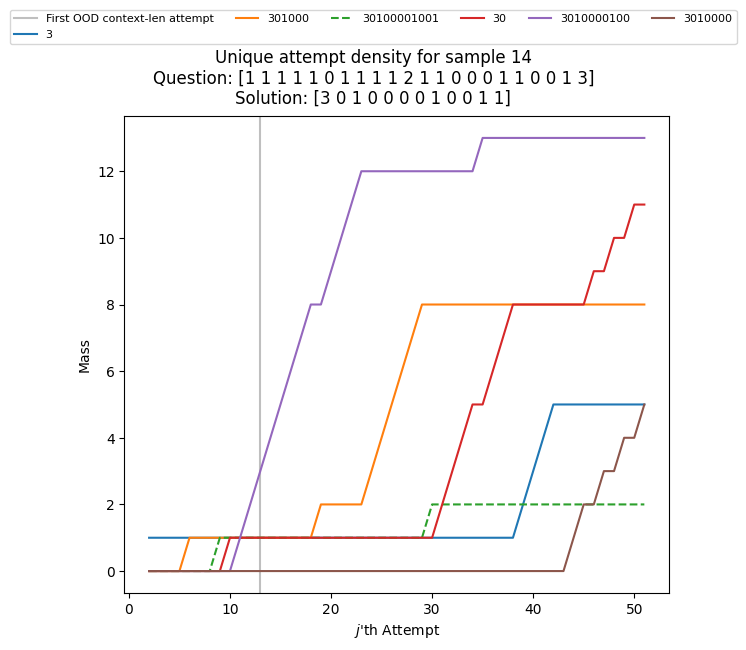

Sample: 15, Success: False, Required attempts: 360


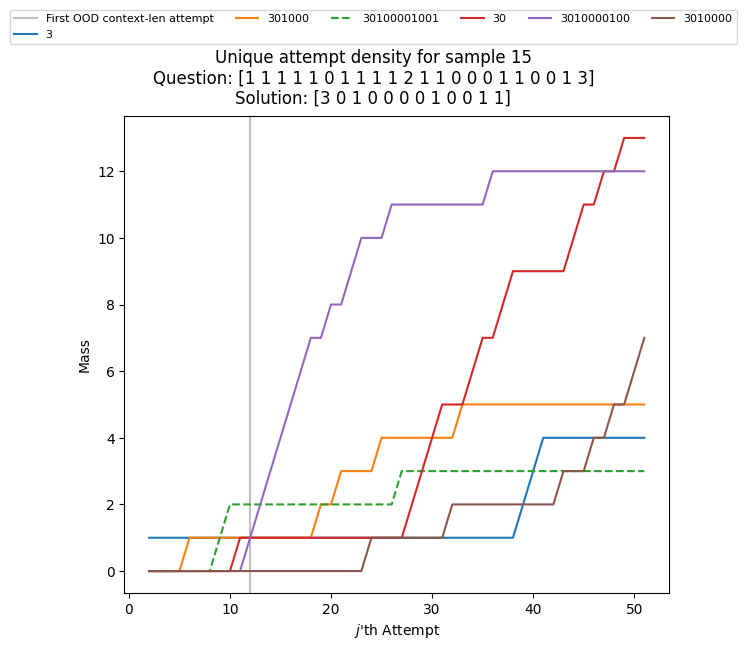

Sample: 16, Success: True, Required attempts: 8


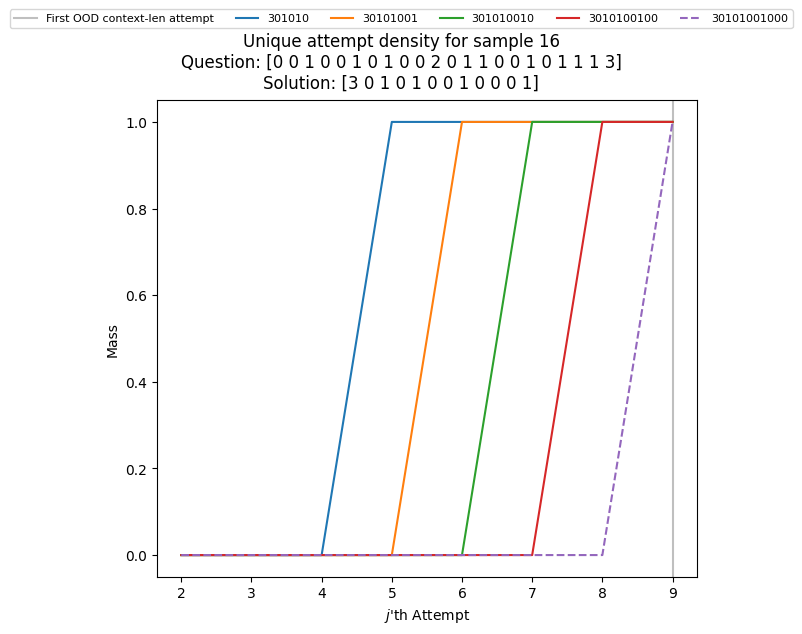

Sample: 17, Success: True, Required attempts: 8


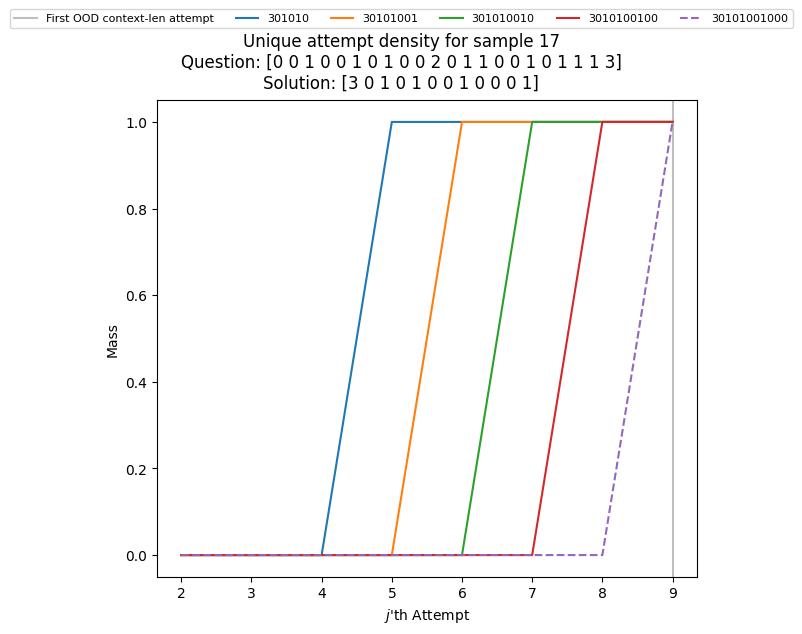

Sample: 18, Success: True, Required attempts: 8


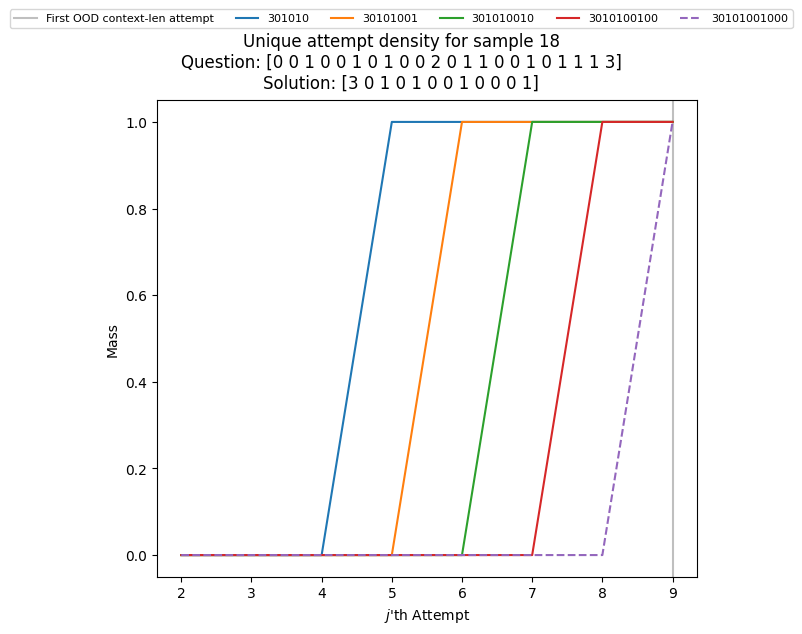

Sample: 19, Success: True, Required attempts: 8


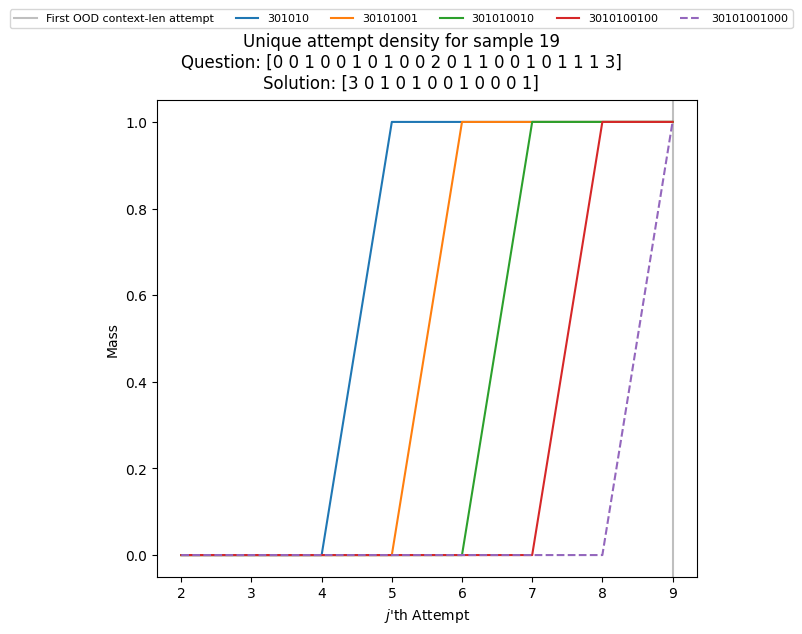

Sample: 20, Success: True, Required attempts: 8


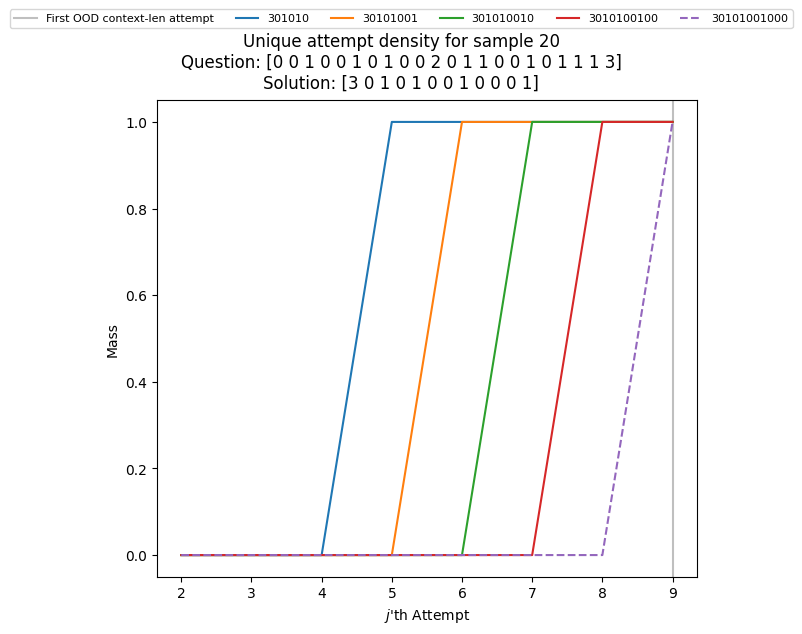

Sample: 21, Success: True, Required attempts: 8


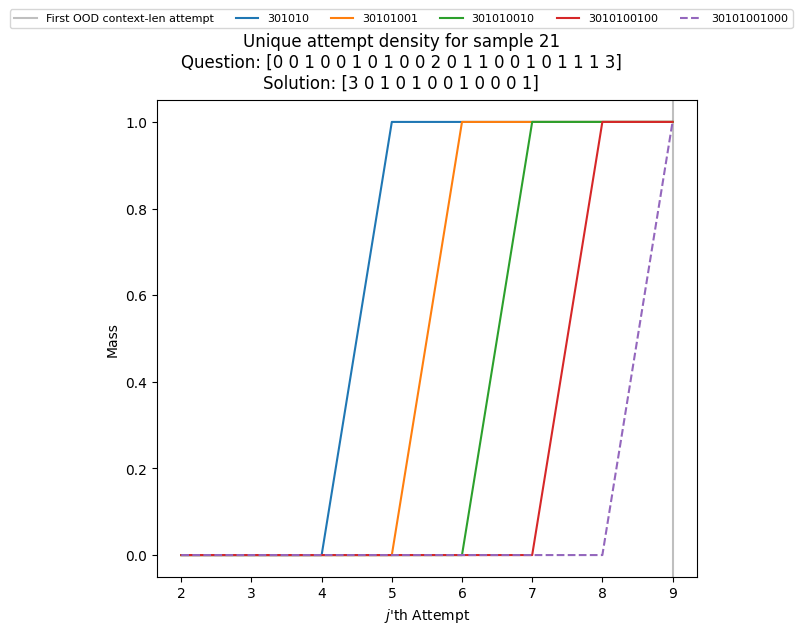

Sample: 22, Success: True, Required attempts: 8


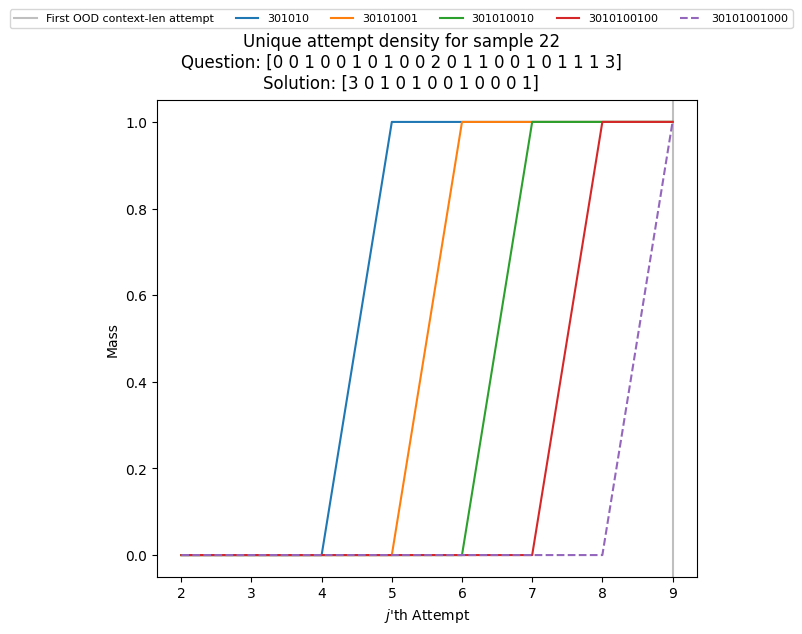

Sample: 23, Success: True, Required attempts: 8


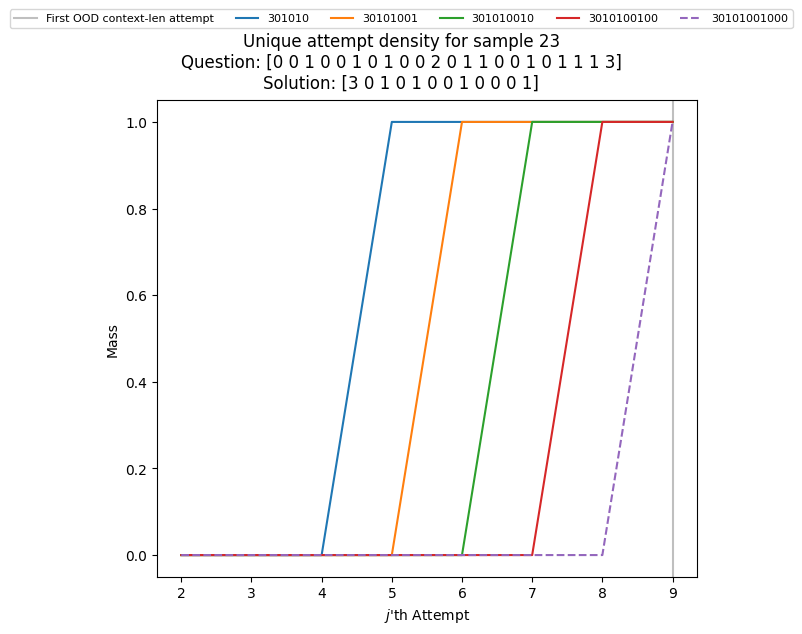

Sample: 24, Success: True, Required attempts: 7


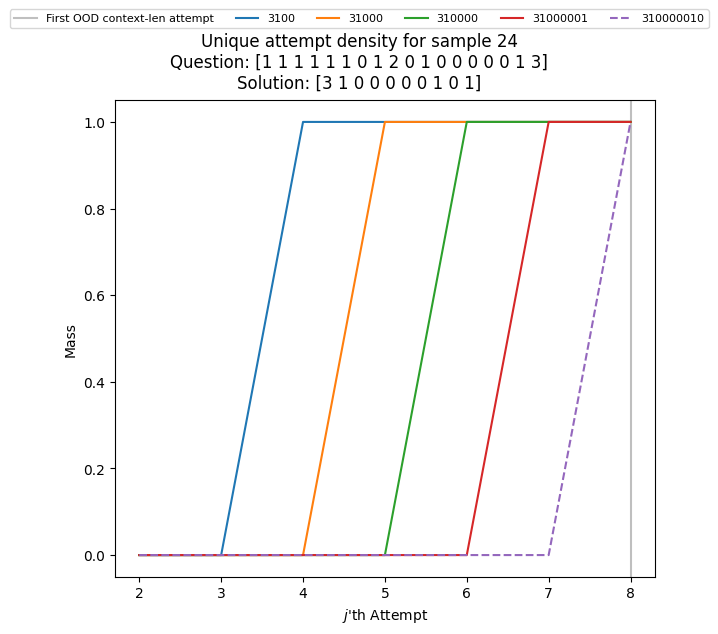

Sample: 25, Success: True, Required attempts: 7


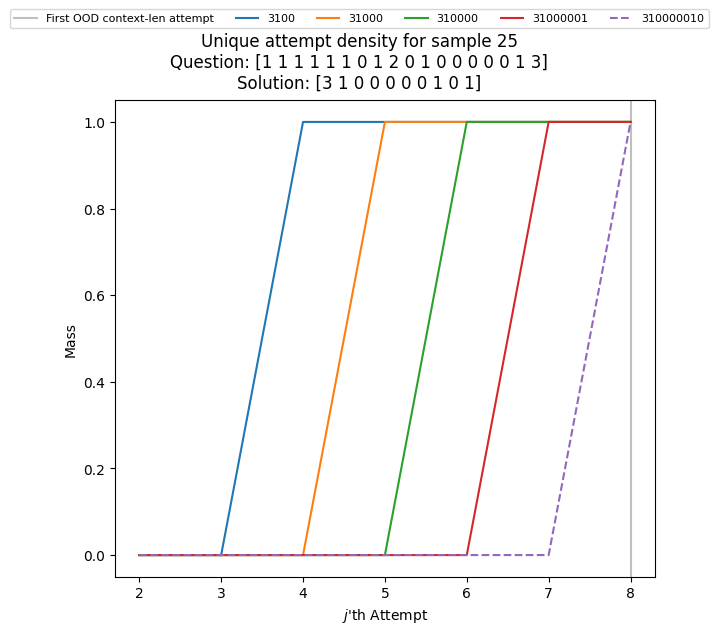

Sample: 26, Success: True, Required attempts: 7


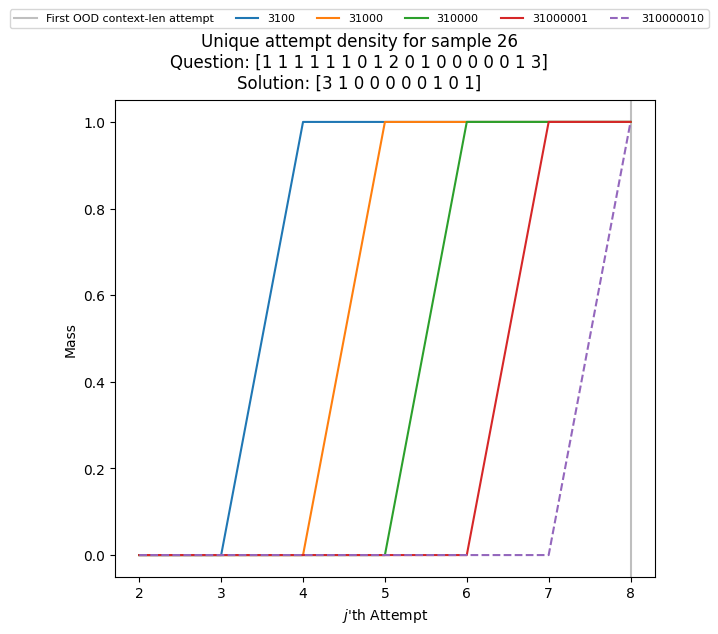

Sample: 27, Success: True, Required attempts: 7


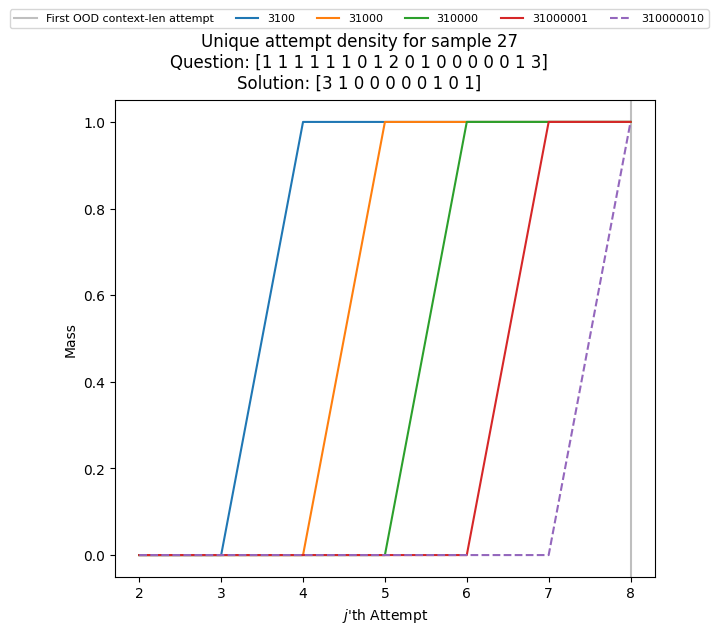

Sample: 28, Success: True, Required attempts: 7


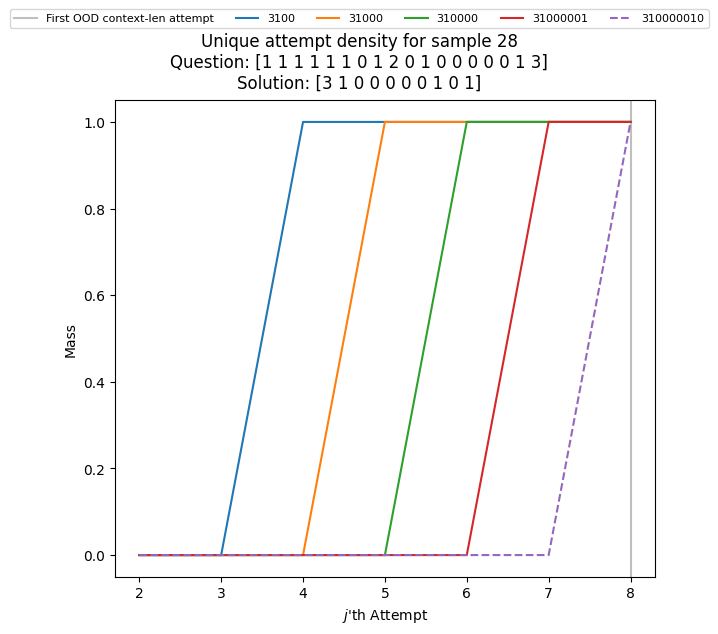

Sample: 29, Success: True, Required attempts: 7


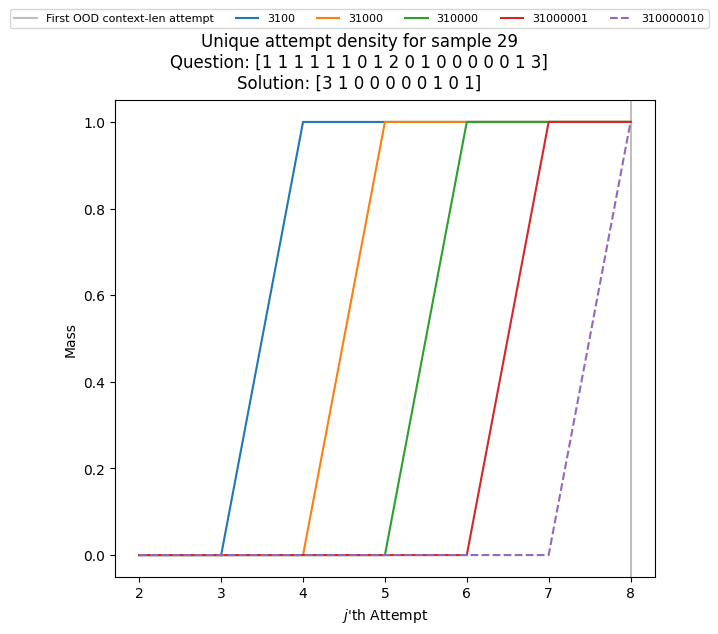

Sample: 30, Success: True, Required attempts: 7


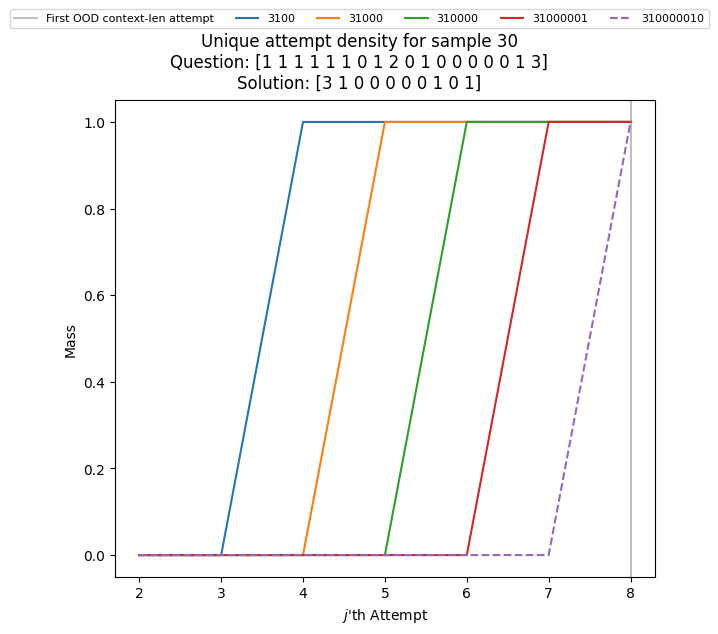

Sample: 31, Success: True, Required attempts: 7


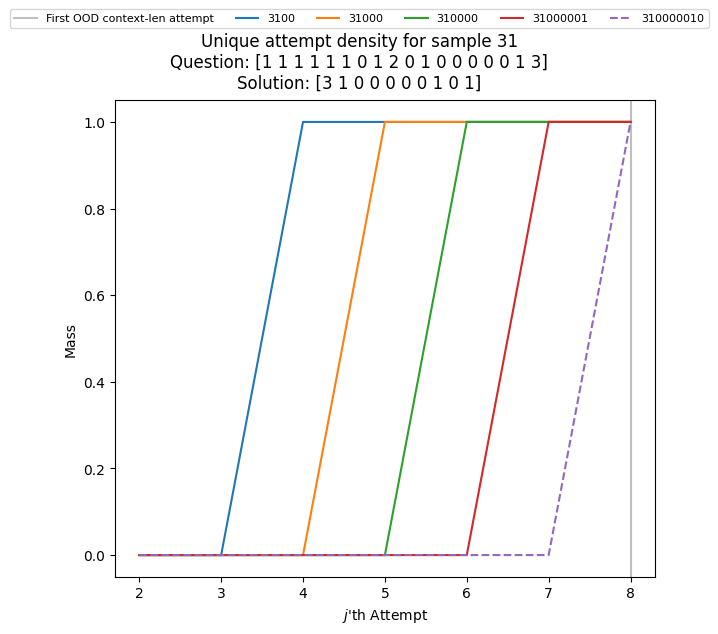

In [ ]:
top_k = 5

for sample_i, curr_trial in enumerate(all_trials):
    # if rollout_res.success[sample_i]:
    #     continue

    num_trials, first_ooc_trial, trial_idxes = curr_trial
    x_range = np.arange(1, num_trials + 1)
    trial_density = {
        k: np.sum(np.array(v)[None] < x_range[:, None], axis=-1) #/ (x_range + 1)
        for k, v in trial_idxes.items()
    }

    fig, ax = plt.subplots(1, 1, layout="constrained", figsize=(6, 6))

    ax.axvline(
        first_ooc_trial + 1, # index off by 1
        c="gray",
        label="First OOD context-len attempt",
        alpha=0.5,
    )

    longest_response_idx = np.argmax([len(v) for v in trial_density.keys()])
    top_k_response_idxes = np.argsort([v[-1] for v in trial_density.values()])[-top_k:]
    for response_i, (k, v) in enumerate(trial_density.items()):
        if (
            response_i not in top_k_response_idxes
            and
            response_i != longest_response_idx
        ):
            continue

        ax.plot(
            (x_range + 1)[:50],
            v[:50],
            label=k,
            linestyle="--" if response_i == longest_response_idx else "-"
        )

    print("Sample: {}, Success: {}, Required attempts: {}".format(
        sample_i,
        rollout_res.success[sample_i],
        num_trials,
    ))
    fig.suptitle(
        "Unique attempt density for sample {}\nQuestion: {}\nSolution: {}".format(
            sample_i,
            batch["sequence"][sample_i][:np.where(batch["sequence"][sample_i] == dataset.eos_token_id)[0][0]],
            batch["target"][sample_i][:np.where(batch["target"][sample_i] == dataset.eos_token_id)[0][0]],
        )
    )
    ax.set_ylabel("Mass")
    ax.set_xlabel("$j$'th Attempt")
    fig.legend(
        bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
        loc="lower center",
        ncols=6,
        borderaxespad=0.0,
        frameon=True,
        fontsize="8",
    )
    plt.show()